# Customer Segmentation

* Download the dataset:

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* Load each datasets:

In [3]:
customers = pd.read_csv(path + '/olist_customers_dataset.csv')
orders = pd.read_csv(path + '/olist_orders_dataset.csv')
order_items = pd.read_csv(path + '/olist_order_items_dataset.csv')
order_payments = pd.read_csv(path + '/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(path + '/olist_order_reviews_dataset.csv')
products = pd.read_csv(path + '/olist_products_dataset.csv')
sellers = pd.read_csv(path + '/olist_sellers_dataset.csv')
geolocation = pd.read_csv(path + '/olist_geolocation_dataset.csv')
translations = pd.read_csv(path + '/product_category_name_translation.csv')

## Feature Engineering

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translations": translations
}

for name, df in datasets.items():
    print(f"\n{name.upper()} columns:\n{df.columns.tolist()}")



CUSTOMERS columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

ORDER_PAYMENTS columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

ORDER_REVIEWS columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS columns:
['seller_id', 'seller_zip

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
customers.shape

(99441, 5)

In [7]:
(customers['customer_unique_id'].nunique())

96096

In [8]:
(customers.groupby('customer_unique_id')['customer_id'].count()>1).sum()

np.int64(2997)

So we have about 100k customers, about 3000 of whom have ordered more than once.

### Feature Extraction:

* Order details:

In [9]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [10]:
# Calculate Order Delay
orders['delivery_lateness'] = (
    orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']
).dt.days

In [11]:
merge_df = orders[['order_id', 'customer_id', 'delivery_lateness']].merge(customers[['customer_id',
                                                                                     'customer_unique_id',
                                                                                     'customer_state',
                                                                                     'customer_zip_code_prefix']], on='customer_id')

In [12]:
merge_df.head()

,order_id,customer_id,delivery_lateness,customer_unique_id,customer_state,customer_zip_code_prefix
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7.0,7c396fd4830fd04220f754e42b4e5bff,SP,3149
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,5.0,af07308b275d755c9edb36a90c618231,BA,47813
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,17.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,75265
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,12.0,7c142cf63193a1473d2e66489a9ae977,RN,59296
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,9.0,72632f0f9dd73dfee390c9b22eb56dd6,SP,9195


* Price and Freight for each order items:

In [13]:
merge_df = merge_df.merge(order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], on='order_id')

* Category name in English:

In [14]:
products = products.merge(translations[['product_category_name', 'product_category_name_english']], on='product_category_name')
merge_df = merge_df.merge(products[['product_id', 'product_category_name_english']], on='product_id')

* Seller's Zipcode:

In [15]:
merge_df = merge_df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')

* Review Score:

In [16]:
merge_df = merge_df.merge(order_reviews[['order_id', 'review_score']], on='order_id')

* Payment details:

In [17]:
merge_df = merge_df.merge(order_payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']], on='order_id')

* Geolocation settings and distances:

In [18]:
geo_mode = (
    geolocation.groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0],
        'geolocation_lng': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    })
    .reset_index()
)

In [19]:
# Merge customer location
merge_df = merge_df.merge(
    geo_mode,
    how='left',
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix'
)
merge_df.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}, inplace=True)
merge_df.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

# Merge seller location
merge_df = merge_df.merge(
    geo_mode,
    how='left',
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix'
)
merge_df.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}, inplace=True)
merge_df.drop(columns=['geolocation_zip_code_prefix'], inplace=True)


In [20]:
import math

def haversine_df(row):
    lat1, lng1, lat2, lng2 = map(math.radians, [row['customer_lat'], row['customer_lng'],
                                           row['seller_lat'], row['seller_lng']])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlng/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return 6371 * c

merge_df['order_distance'] = merge_df.apply(haversine_df, axis=1)

In [21]:
merge_df.head()

,order_id,customer_id,delivery_lateness,customer_unique_id,customer_state,customer_zip_code_prefix,product_id,seller_id,price,freight_value,...,seller_zip_code_prefix,review_score,payment_type,payment_installments,payment_value,customer_lat,customer_lng,seller_lat,seller_lng,order_distance
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7.0,7c396fd4830fd04220f754e42b4e5bff,SP,3149,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,...,9350,4,credit_card,1,18.12,-23.576281,-46.587276,-23.681607,-46.441143,18.941593
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7.0,7c396fd4830fd04220f754e42b4e5bff,SP,3149,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,...,9350,4,voucher,1,2.00,-23.576281,-46.587276,-23.681607,-46.441143,18.941593
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7.0,7c396fd4830fd04220f754e42b4e5bff,SP,3149,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,...,9350,4,voucher,1,18.59,-23.576281,-46.587276,-23.681607,-46.441143,18.941593
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,5.0,af07308b275d755c9edb36a90c618231,BA,47813,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,...,31570,4,boleto,1,141.46,-12.169860,-44.988369,-19.808415,-43.982703,856.131750
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,17.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,75265,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,...,14840,5,credit_card,3,179.12,-16.746337,-48.514624,-21.369332,-48.225907,514.947753


In [22]:
merge_df.shape

(115609, 21)

In [23]:
merge_df.columns.tolist()

['order_id',
 'customer_id',
 'delivery_lateness',
 'customer_unique_id',
 'customer_state',
 'customer_zip_code_prefix',
 'product_id',
 'seller_id',
 'price',
 'freight_value',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'review_score',
 'payment_type',
 'payment_installments',
 'payment_value',
 'customer_lat',
 'customer_lng',
 'seller_lat',
 'seller_lng',
 'order_distance']

## Preprocessing

* Handling Nulls:

In [24]:
merge_df.isnull().sum()

,0
order_id,0
customer_id,0
delivery_lateness,2400
customer_unique_id,0
customer_state,0
customer_zip_code_prefix,0
product_id,0
seller_id,0
price,0
freight_value,0


In [25]:
merge_df = merge_df[merge_df['order_distance'].notna()]
merge_df = merge_df[merge_df['delivery_lateness'].notna()]

* Aggregation:

In [26]:
def get_mode(series):
    mode_series = series.mode()
    return mode_series.iloc[0] if not mode_series.empty else None

# Aggregation Map
agg_dict = {
    'delivery_lateness': 'mean',
    'customer_state': get_mode,
    'price': 'mean',
    'freight_value': 'mean',
    'product_category_name_english': get_mode,
    'review_score': ['mean', 'std'],
    'payment_type': get_mode,
    'payment_installments': 'mean',
    'payment_value': 'mean',
    'order_distance': 'mean'
}

df = merge_df.groupby('customer_unique_id').agg(agg_dict)

df.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in df.columns]
df.reset_index(inplace=True)


df.head()

,customer_unique_id,delivery_lateness_mean,customer_state_get_mode,price_mean,freight_value_mean,product_category_name_english_get_mode,review_score_mean,review_score_std,payment_type_get_mode,payment_installments_mean,payment_value_mean,order_distance_mean
0,0000366f3b9a7992bf8c76cfdf3221e2,4.0,SP,129.90,12.00,bed_bath_table,5.0,NaN,credit_card,8.0,141.90,110.258251
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4.0,SP,18.90,8.29,health_beauty,4.0,NaN,credit_card,1.0,27.19,21.533458
2,0000f46a3911fa3c0805444483337064,1.0,SC,69.00,17.22,stationery,3.0,NaN,credit_card,8.0,86.22,516.664454
3,0000f6ccb0745a6a4b88665a16c9f078,11.0,PA,25.99,17.63,telephony,4.0,NaN,credit_card,4.0,43.62,2481.401210
4,0004aac84e0df4da2b147fca70cf8255,7.0,SP,180.00,16.89,telephony,5.0,NaN,credit_card,6.0,196.89,154.554019


<Axes: >

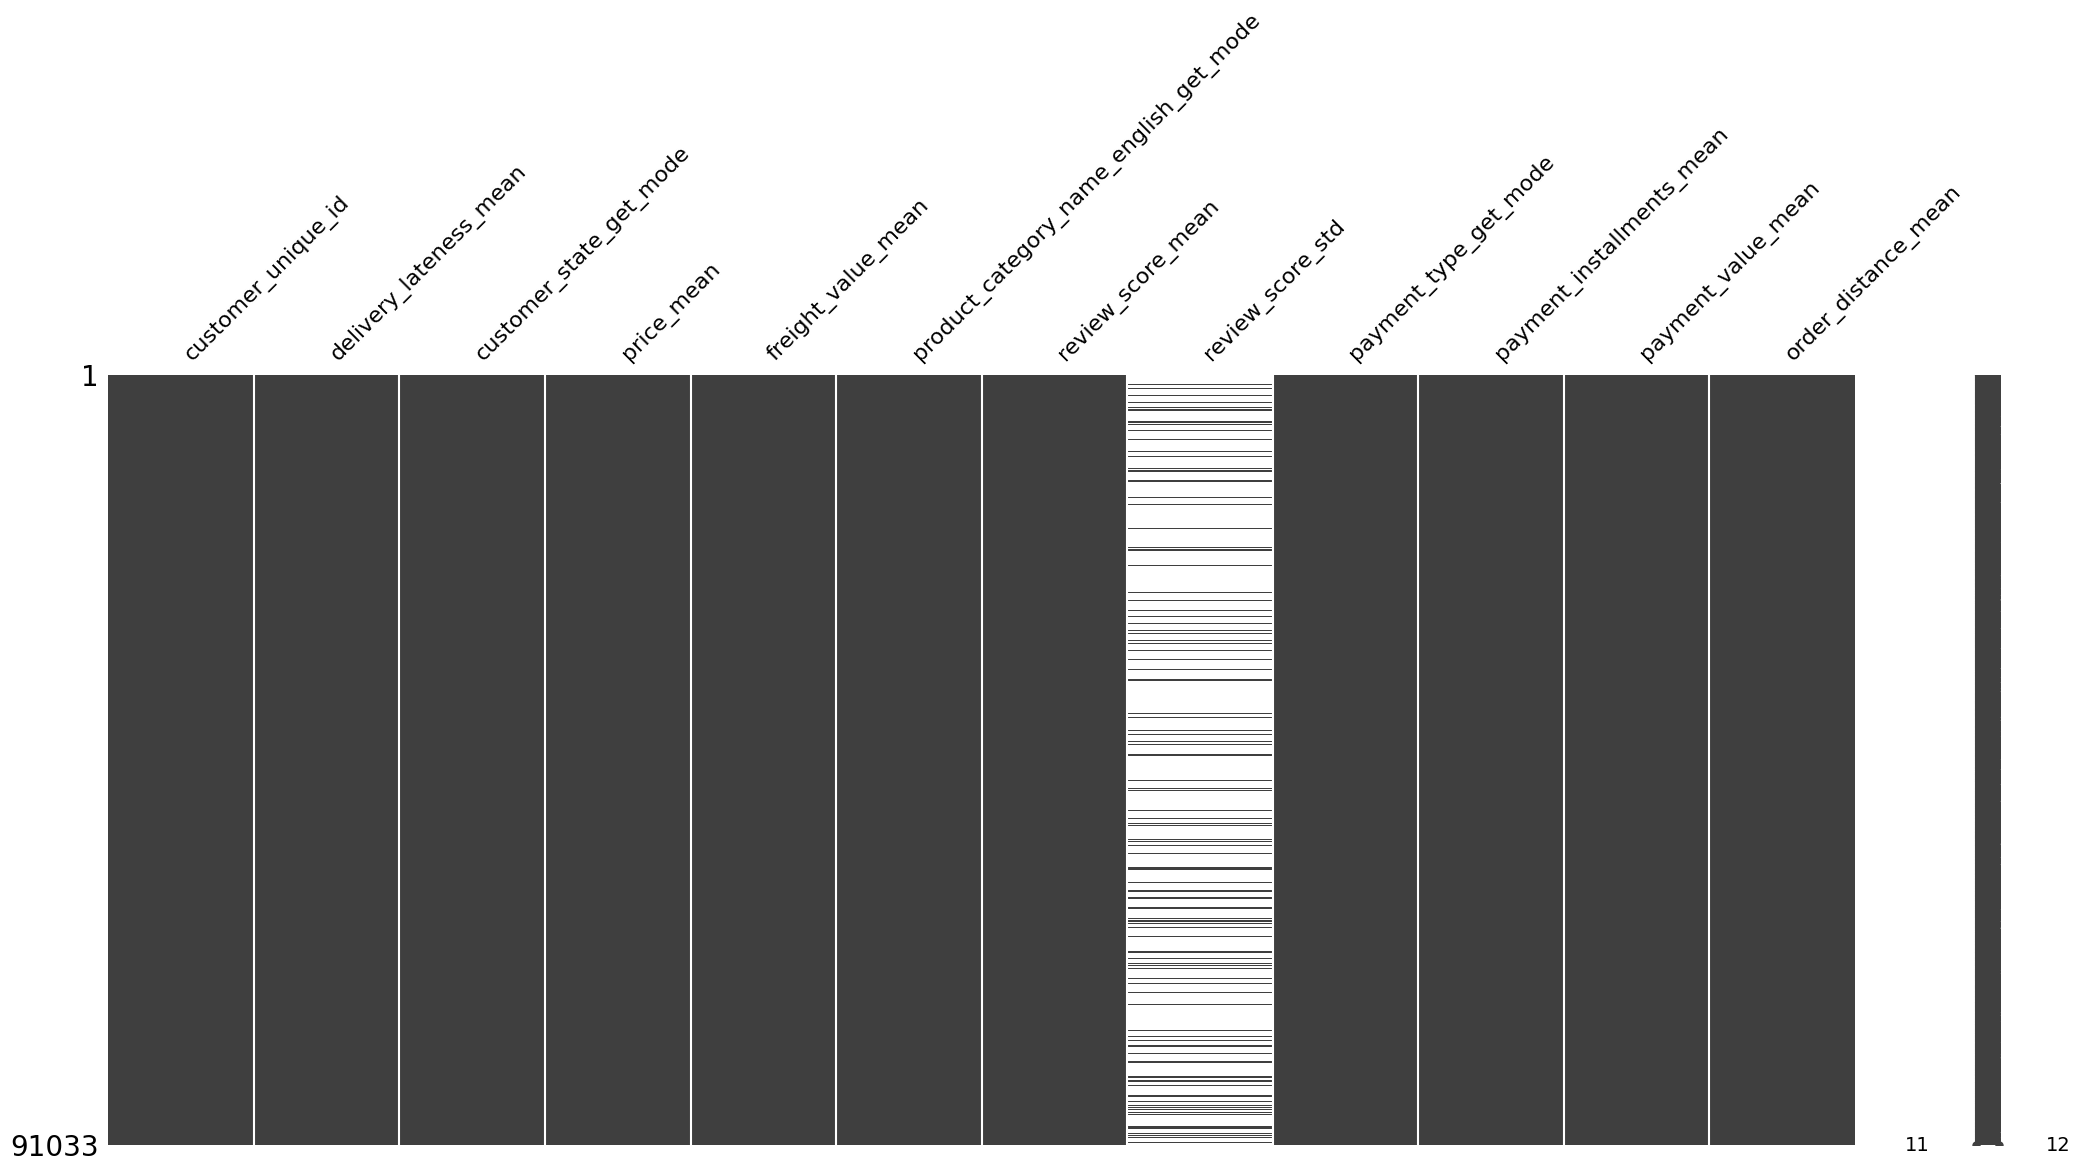

In [27]:
import missingno as msgn
msgn.matrix(df)

In [28]:
df['review_score_std'] = df['review_score_std'].fillna(0)

In [29]:
df.isna().sum()

,0
customer_unique_id,0
delivery_lateness_mean,0
customer_state_get_mode,0
price_mean,0
freight_value_mean,0
product_category_name_english_get_mode,0
review_score_mean,0
review_score_std,0
payment_type_get_mode,0
payment_installments_mean,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91033 entries, 0 to 91032
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   customer_unique_id                      91033 non-null  object 
 1   delivery_lateness_mean                  91033 non-null  float64
 2   customer_state_get_mode                 91033 non-null  object 
 3   price_mean                              91033 non-null  float64
 4   freight_value_mean                      91033 non-null  float64
 5   product_category_name_english_get_mode  91033 non-null  object 
 6   review_score_mean                       91033 non-null  float64
 7   review_score_std                        91033 non-null  float64
 8   payment_type_get_mode                   91033 non-null  object 
 9   payment_installments_mean               91033 non-null  float64
 10  payment_value_mean                      91033 non-null  fl

### EDA

#### Categorical:

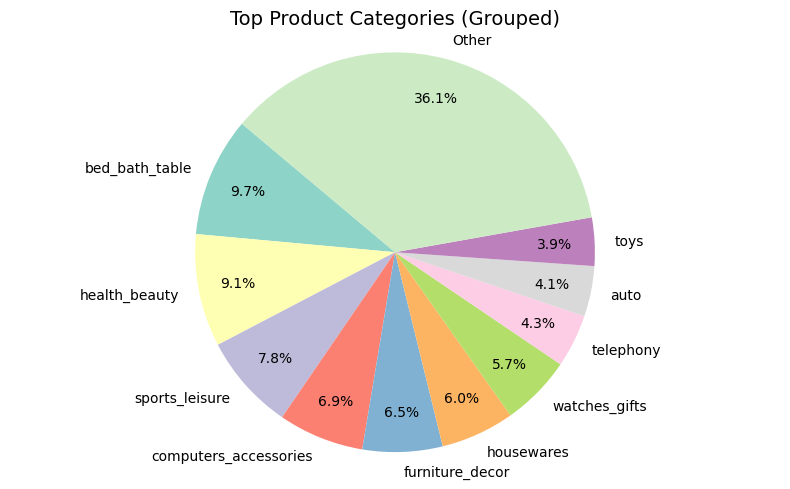

In [31]:
category_counts = df['product_category_name_english_get_mode'].value_counts()

# Top 10 + 'Other'
top_n = 10
top_categories = category_counts[:top_n]
other_count = category_counts[top_n:].sum()
pie_data = pd.concat([top_categories, pd.Series({'Other': other_count})])

colors = plt.get_cmap('Set3').colors[:len(pie_data)]

# Remove label for "Other"
labels = [label if label != 'Other' else 'Other' for label in pie_data.index]

# Plot
plt.figure(figsize=(8, 5))
plt.pie(
    pie_data,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8  # push percent texts outward
)
plt.title('Top Product Categories (Grouped)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

Note: One-hot with 11 categories

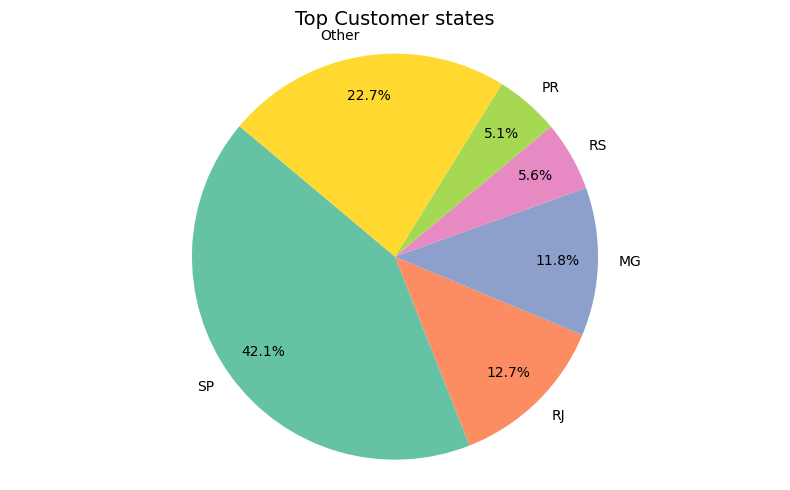

In [32]:
state_counts = df['customer_state_get_mode'].value_counts()

# Top 5 + 'Other'
top_n = 5
top_states = state_counts[:top_n]
other_count = state_counts[top_n:].sum()
pie_data = pd.concat([top_states, pd.Series({'Other': other_count})])

colors = plt.get_cmap('Set2').colors[:len(pie_data)]

# Remove label for "Other"
labels = [label if label != 'Other' else 'Other' for label in pie_data.index]

# Plot
plt.figure(figsize=(8, 5))
plt.pie(
    pie_data,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8  # push percent texts outward
)
plt.title('Top Customer states', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

Note: One-hot with 6 categories

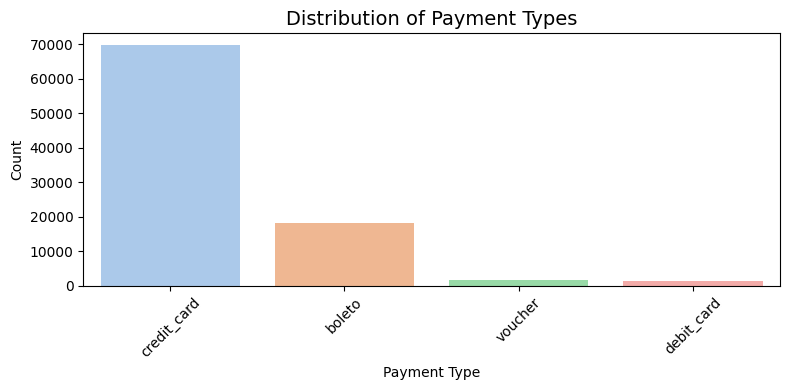

In [33]:
# Count the occurrences of each payment type
payment_counts = df['payment_type_get_mode'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=payment_counts, x='payment_type', y='count', palette='pastel')

plt.title('Distribution of Payment Types', fontsize=14)
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Numerical:

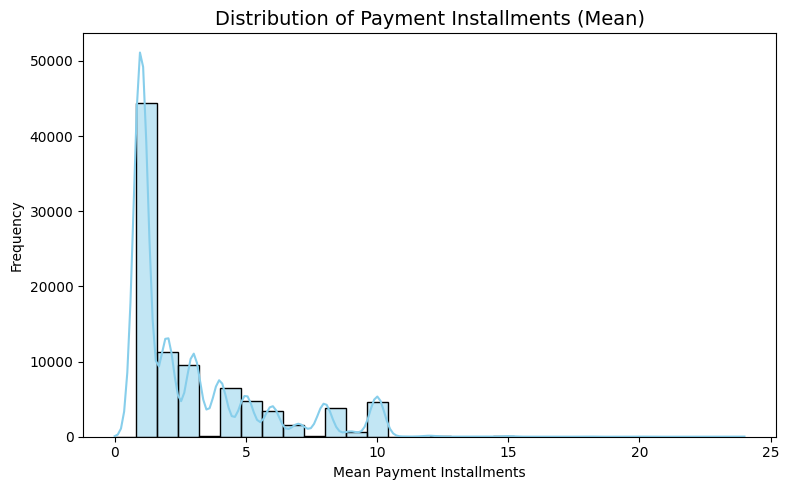

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df['payment_installments_mean'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Payment Installments (Mean)', fontsize=14)
plt.xlabel('Mean Payment Installments')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Note: the values are heavily skewed, normalization or transformation should be done.

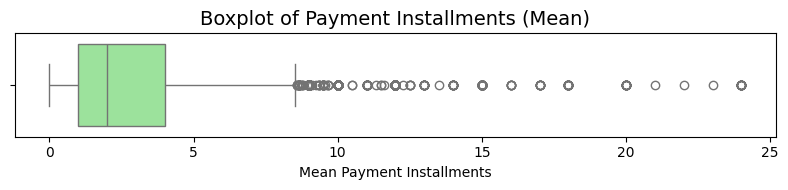

In [35]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['payment_installments_mean'], color='lightgreen')

plt.title('Boxplot of Payment Installments (Mean)', fontsize=14)
plt.xlabel('Mean Payment Installments')
plt.tight_layout()
plt.show()

In [36]:
bins = [0, 10, 15, 20, 25]
labels = ['0-10', '10-15', '15-20', '20-25']

bin_counts = pd.cut(df['payment_installments_mean'], bins=bins, labels=labels, right=False).value_counts().sort_index()

print(bin_counts)


payment_installments_mean
0-10     86163
10-15     4740
15-20       97
20-25       33
Name: count, dtype: int64


The last two bins (15–25) together account for only 130 out of 91,033 (~0.14%), which is extremely small and may introduce noise or bias clustering, especially for algorithms sensitive to outliers like KMeans.
Removing Outliers:

In [37]:
df = df[df['payment_installments_mean'] <= 15]

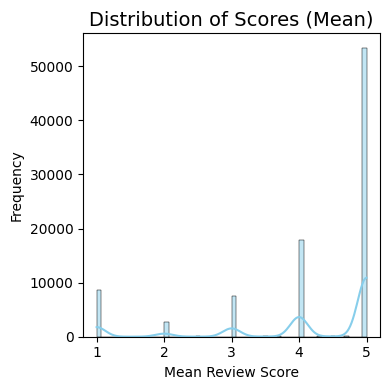

In [38]:
plt.figure(figsize=(4, 4))
sns.histplot(df['review_score_mean'], bins=60, kde=True, color='skyblue')

plt.title('Distribution of Scores (Mean)', fontsize=14)
plt.xlabel('Mean Review Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

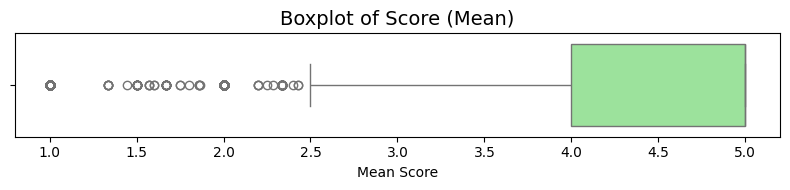

In [39]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['review_score_mean'], color='lightgreen')

plt.title('Boxplot of Score (Mean)', fontsize=14)
plt.xlabel('Mean Score')
plt.tight_layout()
plt.show()

In [40]:
# Exact review scores
exact_counts = df['review_score_mean'].value_counts().sort_index()
exact_integers = exact_counts[exact_counts.index.isin([1.0, 2.0, 3.0, 4.0, 5.0])]

# Ranges
bins = [1, 2, 3, 4, 5]
labels = ['1-2', '2-3', '3-4', '4-5']
range_counts = pd.cut(df['review_score_mean'], bins=bins, right=False, labels=labels).value_counts().sort_index()

print("Exact Integer Review Score Counts:")
print(exact_integers)
print("\nCounts in Ranges:")
print(range_counts)


Exact Integer Review Score Counts:
review_score_mean
1.0     8703
2.0     2762
3.0     7525
4.0    17810
5.0    53430
Name: count, dtype: int64

Counts in Ranges:
review_score_mean
1-2     8746
2-3     2874
3-4     7735
4-5    18180
Name: count, dtype: int64


Note: scaling with z-score normalization is necessary.

* Price and Payment:

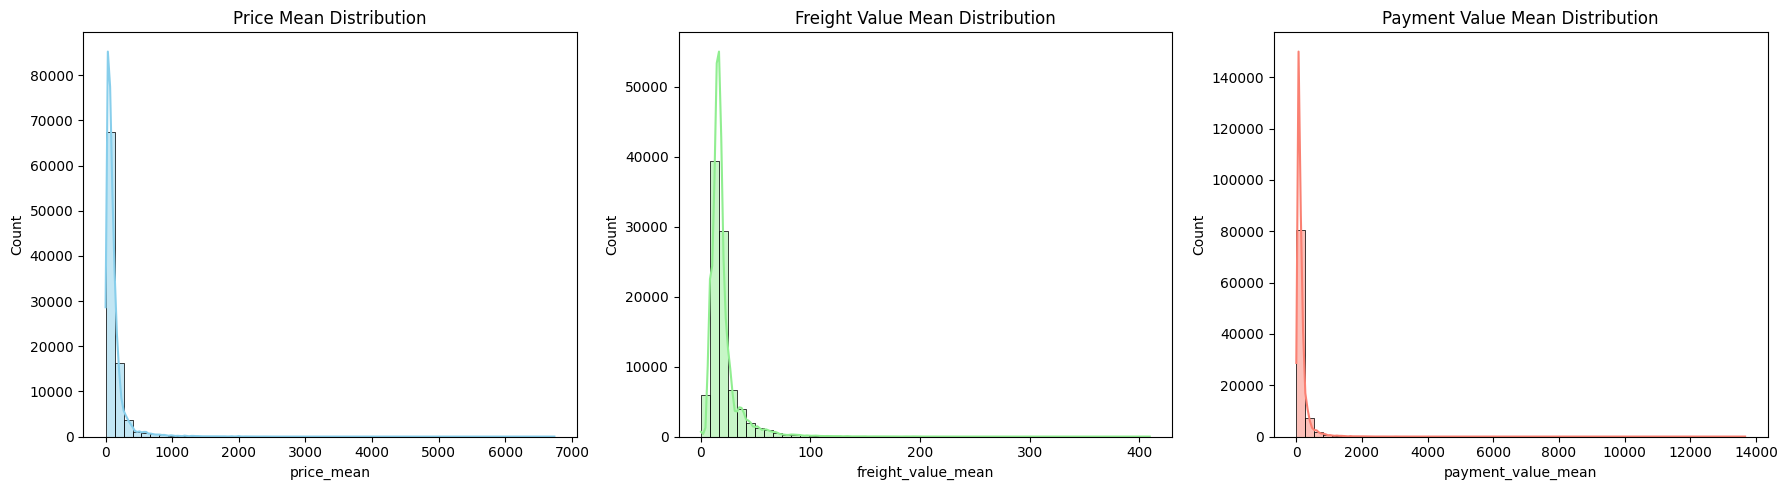

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['price_mean'], bins=50, kde=True, color='skyblue', ax=axs[0])
axs[0].set_title('Price Mean Distribution')

sns.histplot(df['freight_value_mean'], bins=50, kde=True, color='lightgreen', ax=axs[1])
axs[1].set_title('Freight Value Mean Distribution')

sns.histplot(df['payment_value_mean'], bins=50, kde=True, color='salmon', ax=axs[2])
axs[2].set_title('Payment Value Mean Distribution')

plt.tight_layout()
plt.show()


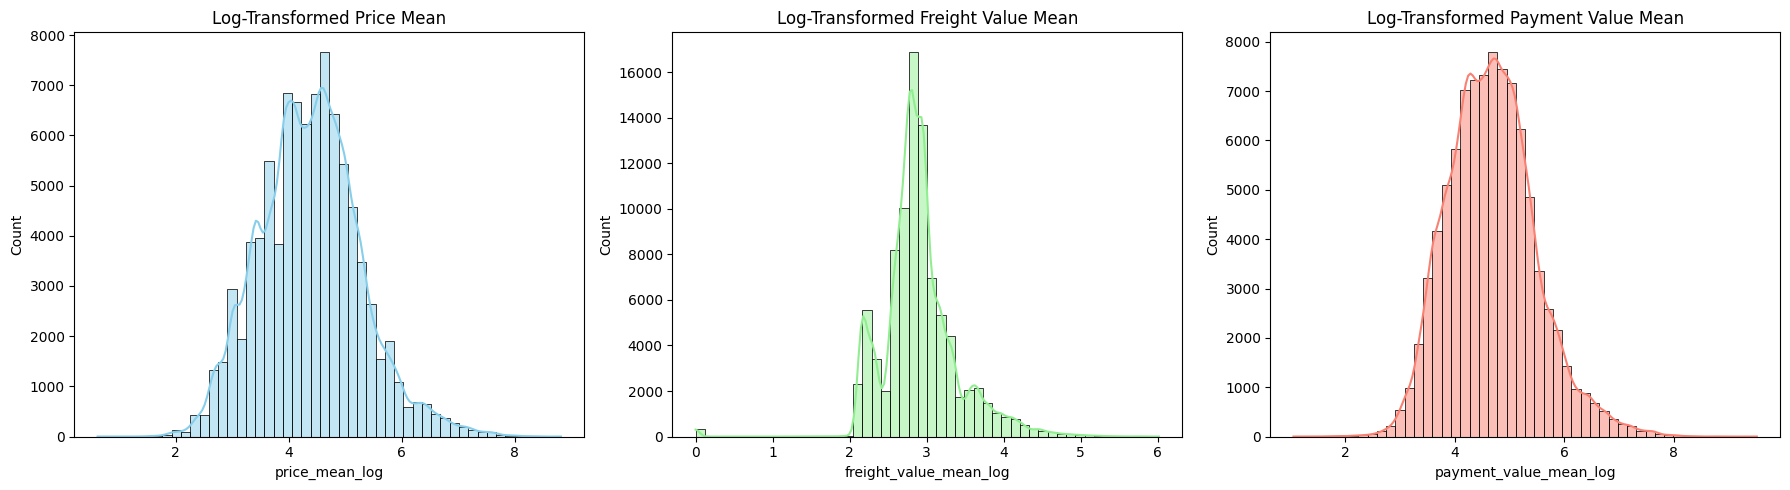

In [42]:
# log scale
df_log = df.copy()
df_log['price_mean_log'] = np.log1p(df['price_mean'])
df_log['freight_value_mean_log'] = np.log1p(df['freight_value_mean'])
df_log['payment_value_mean_log'] = np.log1p(df['payment_value_mean'])


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_log['price_mean_log'], bins=50, kde=True, color='skyblue', ax=axs[0])
axs[0].set_title('Log-Transformed Price Mean')

sns.histplot(df_log['freight_value_mean_log'], bins=50, kde=True, color='lightgreen', ax=axs[1])
axs[1].set_title('Log-Transformed Freight Value Mean')

sns.histplot(df_log['payment_value_mean_log'], bins=50, kde=True, color='salmon', ax=axs[2])
axs[2].set_title('Log-Transformed Payment Value Mean')

plt.tight_layout()
plt.show()

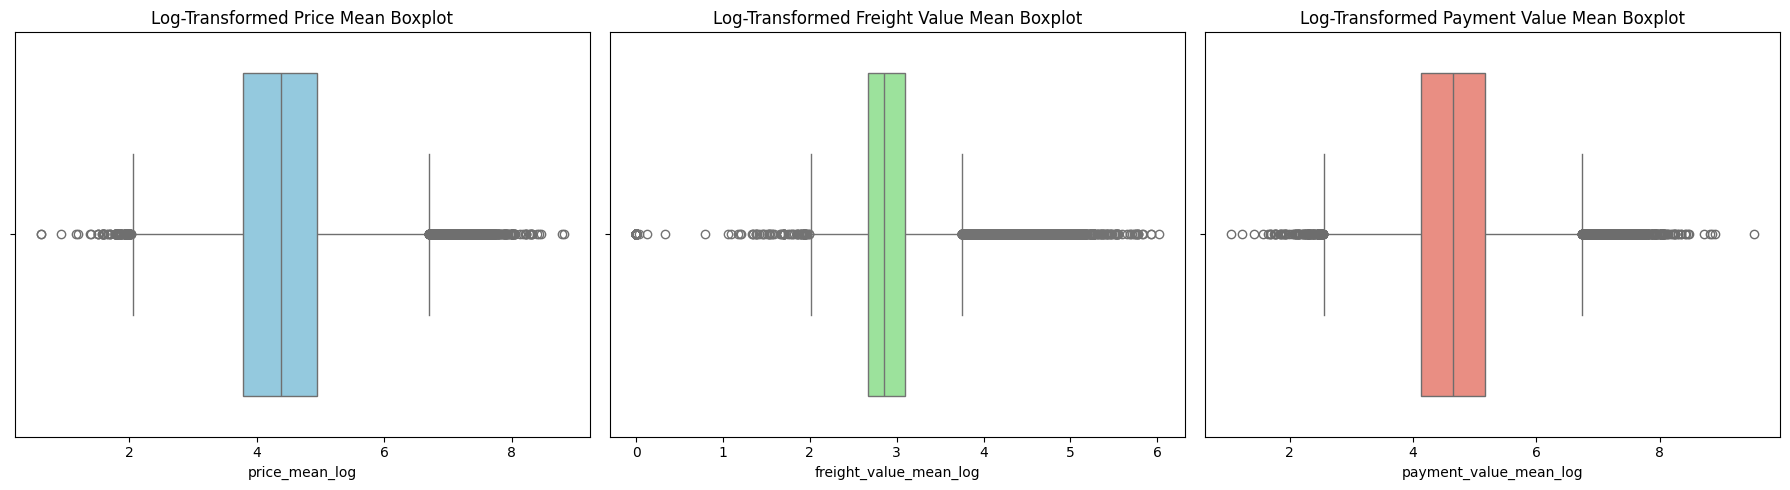

In [43]:
# Boxplot (log scale)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df_log['price_mean_log'], color='skyblue', ax=axs[0])
axs[0].set_title('Log-Transformed Price Mean Boxplot')

sns.boxplot(x=df_log['freight_value_mean_log'], color='lightgreen', ax=axs[1])
axs[1].set_title('Log-Transformed Freight Value Mean Boxplot')

sns.boxplot(x=df_log['payment_value_mean_log'], color='salmon', ax=axs[2])
axs[2].set_title('Log-Transformed Payment Value Mean Boxplot')

plt.tight_layout()
plt.show()

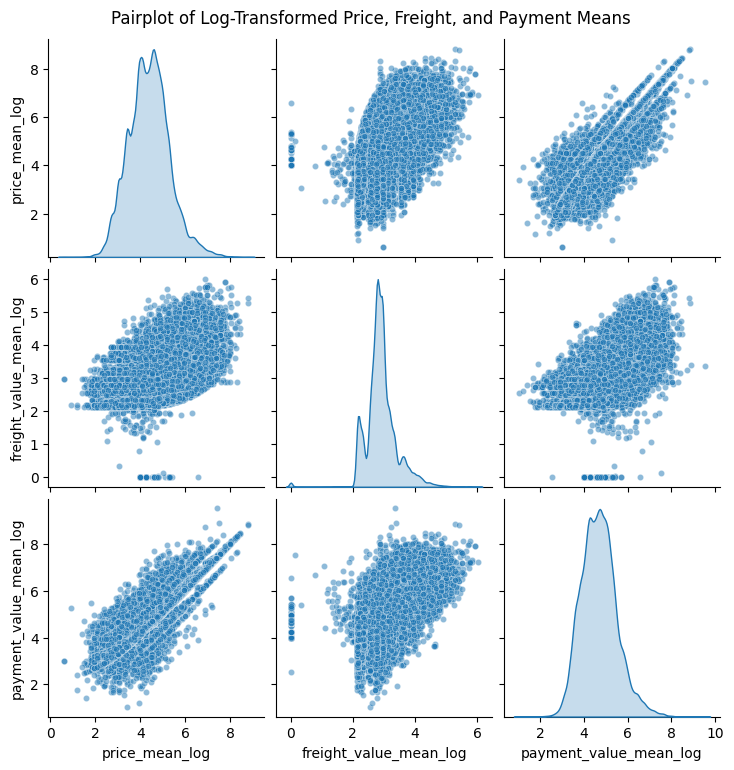

In [44]:
# Pairplot (log scale)
sns.pairplot(
    df_log[['price_mean_log', 'freight_value_mean_log', 'payment_value_mean_log']],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kws={'shade': True}
)
plt.suptitle('Pairplot of Log-Transformed Price, Freight, and Payment Means', y=1.02)
plt.show()

A correlation can be observed between 'price_mean' and 'payment_value_mean'. Which makes sense because the customer has to pay the 'payment', which is calculated from 'price'.

* Distance and Lateness:

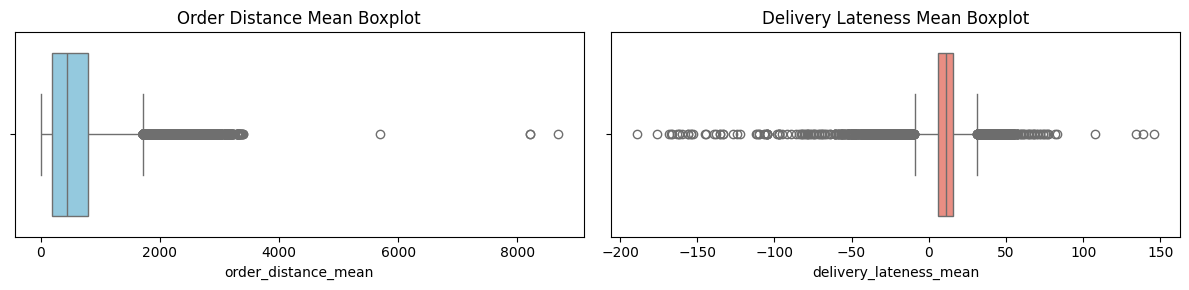

In [45]:
# Boxplots
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

sns.boxplot(x=df['order_distance_mean'], color='skyblue', ax=axs[0])
axs[0].set_title('Order Distance Mean Boxplot')

sns.boxplot(x=df['delivery_lateness_mean'], color='salmon', ax=axs[1])
axs[1].set_title('Delivery Lateness Mean Boxplot')

plt.tight_layout()
plt.show()

Removing Outliers:

In [46]:
df = df[df['order_distance_mean'] <= 4000]
df = df[df['delivery_lateness_mean'] <= 100]
df = df[df['delivery_lateness_mean'] >= -150]

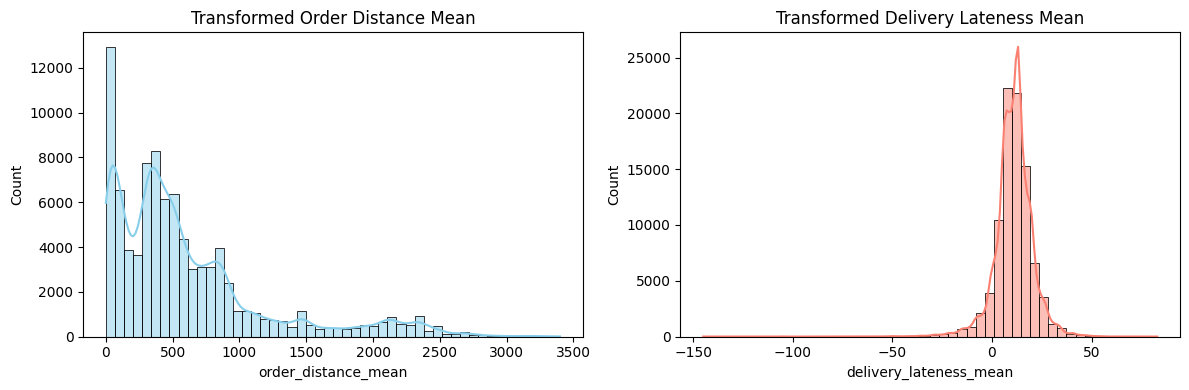

In [47]:
# Histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['order_distance_mean'], bins=50, kde=True, color='skyblue', ax=axs[0])
axs[0].set_title('Transformed Order Distance Mean')

sns.histplot(df['delivery_lateness_mean'], bins=50, kde=True, color='salmon', ax=axs[1])
axs[1].set_title('Transformed Delivery Lateness Mean')

plt.tight_layout()
plt.show()


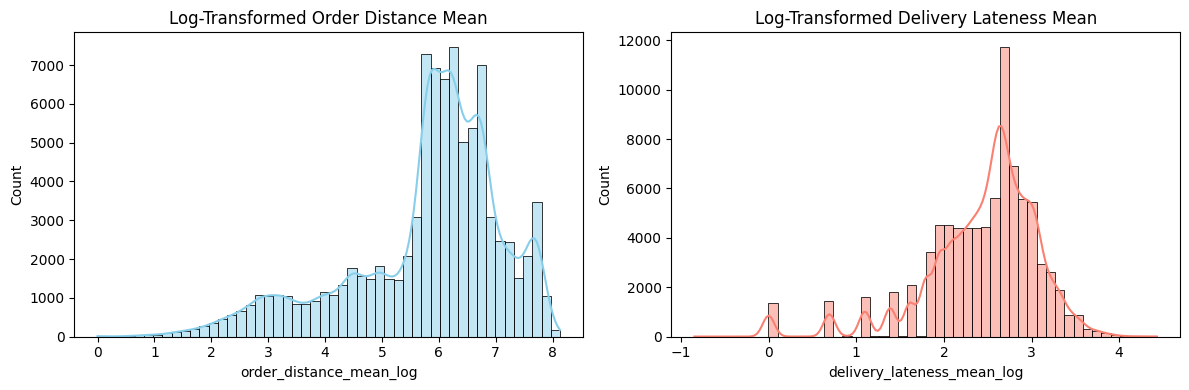

In [48]:
# Log-transform
df_log = df.copy()
df_log['order_distance_mean_log'] = np.log1p(df['order_distance_mean'])
df_log['delivery_lateness_mean_log'] = np.log1p(df['delivery_lateness_mean'])

# Histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_log['order_distance_mean_log'], bins=50, kde=True, color='skyblue', ax=axs[0])
axs[0].set_title('Log-Transformed Order Distance Mean')

sns.histplot(df_log['delivery_lateness_mean_log'], bins=50, kde=True, color='salmon', ax=axs[1])
axs[1].set_title('Log-Transformed Delivery Lateness Mean')

plt.tight_layout()
plt.show()


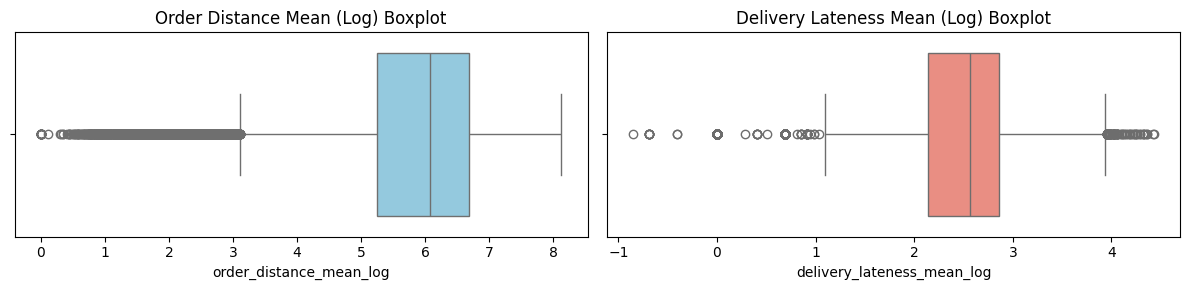

In [49]:
# Boxplots
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

sns.boxplot(x=df_log['order_distance_mean_log'], color='skyblue', ax=axs[0])
axs[0].set_title('Order Distance Mean (Log) Boxplot')

sns.boxplot(x=df_log['delivery_lateness_mean_log'], color='salmon', ax=axs[1])
axs[1].set_title('Delivery Lateness Mean (Log) Boxplot')

plt.tight_layout()
plt.show()

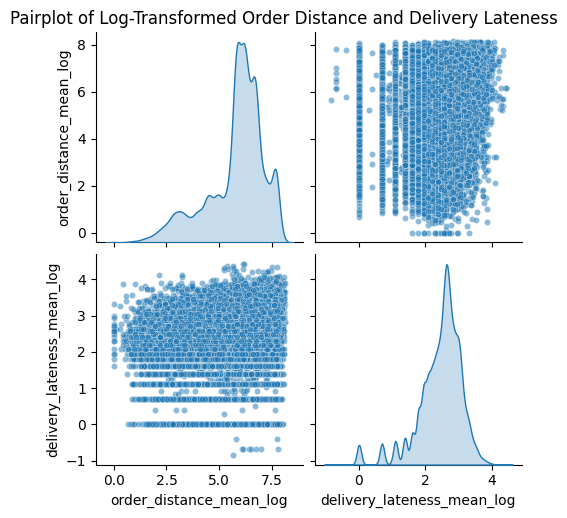

In [50]:
# Pairplot (if needed)
sns.pairplot(
    df_log[['order_distance_mean_log', 'delivery_lateness_mean_log']],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kws={'shade': True}
)
plt.suptitle('Pairplot of Log-Transformed Order Distance and Delivery Lateness', y=1.02)
plt.show()

### Encoding

In [51]:
df_encoded = df.copy()
df_encoded.drop(columns=['customer_unique_id'], inplace=True)

In [52]:
# One-hot encode product_category_name_english_get_mode (top 10 + 'Other')
top_10_products = df_encoded['product_category_name_english_get_mode'].value_counts().nlargest(10).index
df_encoded['product_category_grouped'] = df_encoded['product_category_name_english_get_mode'].where(
    df_encoded['product_category_name_english_get_mode'].isin(top_10_products), 'Other'
)
df_encoded = pd.get_dummies(df_encoded, columns=['product_category_grouped'], prefix='product')

# Drop original column
df_encoded.drop(columns=['product_category_name_english_get_mode'], inplace=True)


In [53]:
# One-hot encode customer_state_get_mode (top 5 + 'Other')
top_5_states = df_encoded['customer_state_get_mode'].value_counts().nlargest(5).index
df_encoded['state_grouped'] = df_encoded['customer_state_get_mode'].where(
    df_encoded['customer_state_get_mode'].isin(top_5_states), 'Other'
)
df_encoded = pd.get_dummies(df_encoded, columns=['state_grouped'], prefix='state')

# Drop original column
df_encoded.drop(columns=['customer_state_get_mode'], inplace=True)


In [54]:
# One-hot encode payment_type_get_mode
df_encoded = pd.get_dummies(df_encoded, columns=['payment_type_get_mode'], prefix='payment_type')

df_encoded.head()

,delivery_lateness_mean,price_mean,freight_value_mean,review_score_mean,review_score_std,payment_installments_mean,payment_value_mean,order_distance_mean,product_Other,product_auto,...,state_MG,state_Other,state_PR,state_RJ,state_RS,state_SP,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,4.0,129.90,12.00,5.0,0.0,8.0,141.90,110.258251,False,False,...,False,False,False,False,False,True,False,True,False,False
1,4.0,18.90,8.29,4.0,0.0,1.0,27.19,21.533458,False,False,...,False,False,False,False,False,True,False,True,False,False
2,1.0,69.00,17.22,3.0,0.0,8.0,86.22,516.664454,True,False,...,False,True,False,False,False,False,False,True,False,False
3,11.0,25.99,17.63,4.0,0.0,4.0,43.62,2481.401210,False,False,...,False,True,False,False,False,False,False,True,False,False
4,7.0,180.00,16.89,5.0,0.0,6.0,196.89,154.554019,False,False,...,False,False,False,False,False,True,False,True,False,False


### Transformation and Normalization

In [55]:
df_transformed = df_encoded.copy()

# Columns to log-transform due to skewness
log_transform_cols = [
    'payment_installments_mean',
    'price_mean',
    'freight_value_mean',
    'payment_value_mean',
    'order_distance_mean',
    'review_score_std'
]

# Apply log1p transform
for col in log_transform_cols:
    df_transformed[col] = np.log1p(df_transformed[col])


In [56]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_transformed.copy()

# StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)

## Clustering

### PCA

In [57]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

n_components_90 = next(i for i, cumsum in enumerate(cumulative_variance) if cumsum >= 0.90) + 1
print(f"\nNumber of components to explain 90% variance: {n_components_90}")


Number of components to explain 90% variance: 21


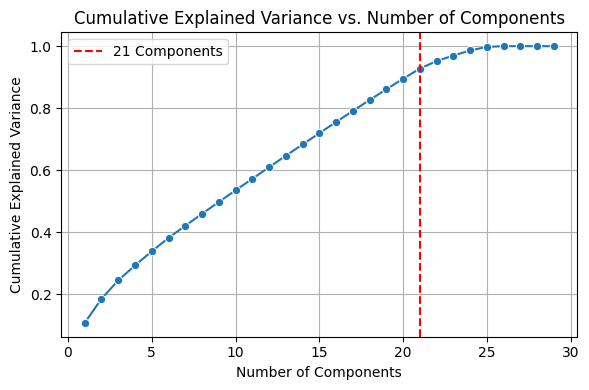

In [58]:
df_variance = pd.DataFrame({
    'Number of Components': range(1, len(explained_variance) + 1),
    'Cumulative Explained Variance': cumulative_variance
})

plt.figure(figsize=(6, 4))
sns.lineplot(data=df_variance, x='Number of Components', y='Cumulative Explained Variance', marker='o')
plt.axvline(x=n_components_90, color='r', linestyle='--', label=f'{n_components_90} Components')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


* Reducing Data:

In [59]:
pca_final = PCA(n_components=n_components_90)
df_reduced = pca_final.fit_transform(df_scaled)

In [60]:
from cuml.cluster import KMeans as cuKMeans
import cupy as cp  # cuML expects cupy arrays (GPU arrays)

# Convert your pandas/numpy data to cupy array
X_gpu = cp.asarray(df_reduced)

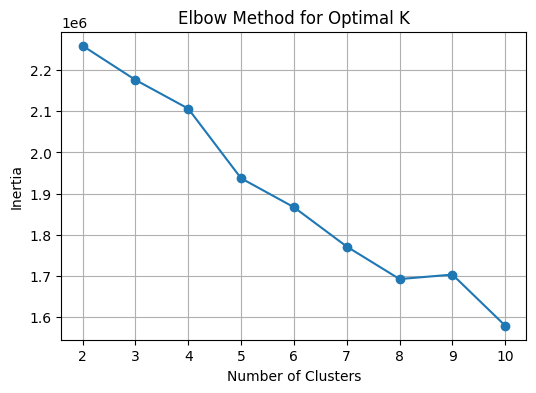

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = cuKMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_gpu)

    inertia.append(kmeans.inertia_)

    # For silhouette, need to bring labels and data back to CPU numpy
    labels = kmeans.labels_.get()

    from sklearn.metrics import silhouette_score
    silhouette_scores.append(silhouette_score(df_reduced, labels))


# Plot Elbow
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

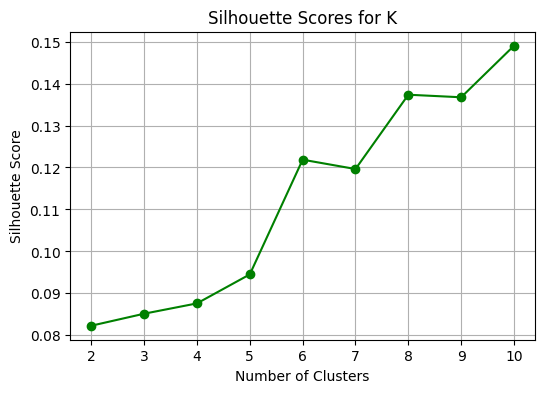

In [62]:
# Plot silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### KMeans

* 10 Clusters:

In [63]:
from sklearn.cluster import KMeans

k = 10

kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(df_reduced)

df_kmeans = pd.DataFrame(df_reduced)
df_kmeans['cluster'] = kmeans.labels_

print(df_kmeans['cluster'].value_counts().sort_index())

cluster
0     3893
1    13506
2     7083
3     5200
4    11592
5    24995
6     8788
7     6299
8     3709
9     5878
Name: count, dtype: int64


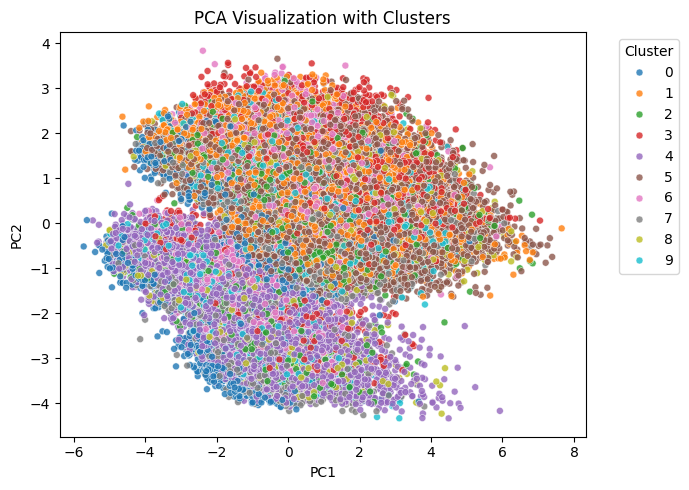

In [64]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_kmeans.drop(columns=['cluster']))


plot_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
plot_df['Cluster'] = df_kmeans['cluster']


plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('PCA Visualization with Clusters')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


* 6 Clusters:

In [65]:
k = 6

kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(df_reduced)

df_kmeans = pd.DataFrame(df_reduced)
df_kmeans['cluster'] = kmeans.labels_

print(df_kmeans['cluster'].value_counts().sort_index())

cluster
0    11747
1    11542
2     5051
3    16325
4    29010
5    17268
Name: count, dtype: int64


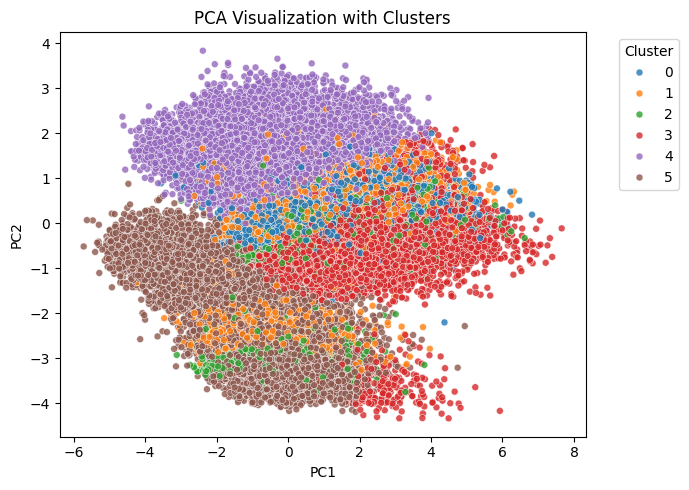

In [66]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_kmeans.drop(columns=['cluster']))


plot_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
plot_df['Cluster'] = df_kmeans['cluster']


plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('PCA Visualization with Clusters')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


* 3 Clusters:

In [67]:
k = 3

kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(df_reduced)

df_kmeans = pd.DataFrame(df_reduced)
df_kmeans['cluster'] = kmeans.labels_

print(df_kmeans['cluster'].value_counts().sort_index())

cluster
0    29113
1    21315
2    40515
Name: count, dtype: int64


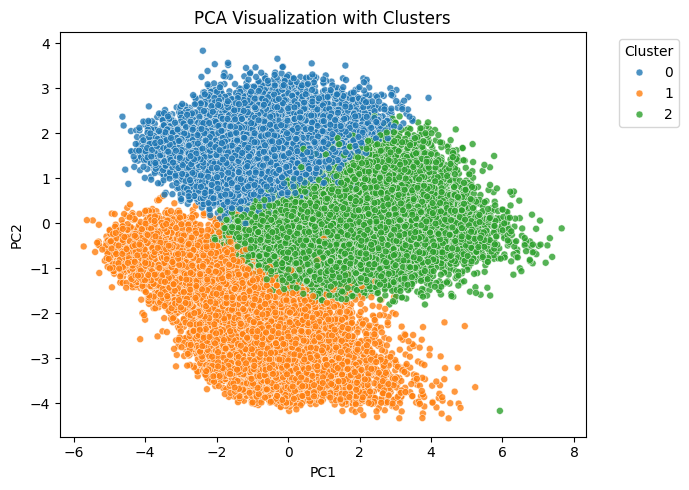

In [68]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_kmeans.drop(columns=['cluster']))


kplot_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
kplot_df['Cluster'] = df_kmeans['cluster']


plt.figure(figsize=(7, 5))
sns.scatterplot(data=kplot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('PCA Visualization with Clusters')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Hierarchical Clustering

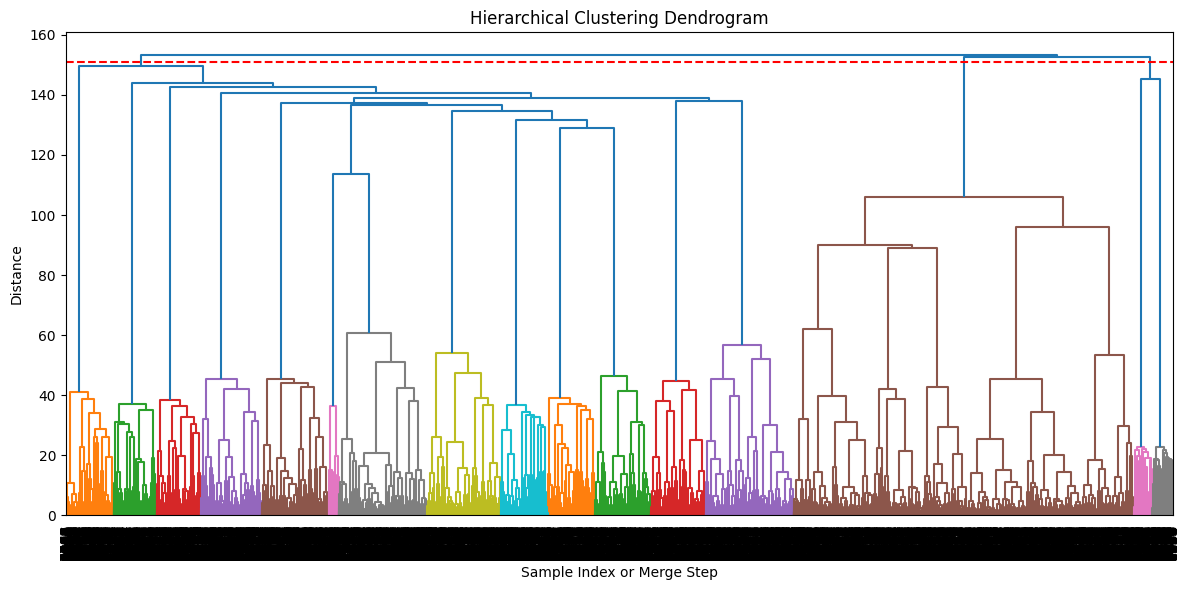

In [69]:
from scipy.cluster.hierarchy import dendrogram, linkage

df_hierarchical = pd.DataFrame(df_reduced).sample(n=10000, random_state=42)

# Compute the linkage matrix
linked = linkage(df_hierarchical, method='ward', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='level',  # only show the last p merged clusters
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

# draw horizontal line to suggest cut-off
plt.axhline(y=151, color='r', linestyle='--')

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Merge Step')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


* 4 Clusters:

In [70]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

df_hierarchical.columns = df_hierarchical.columns.astype(str)

Agglomerative = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'ward')
y_Agglomerative = Agglomerative.fit_predict(df_hierarchical)

df_hierarchical['Cluster'] = y_Agglomerative
df_hierarchical['Cluster'].value_counts()

,count
Cluster,
1,6139
2,3077
3,434
0,350


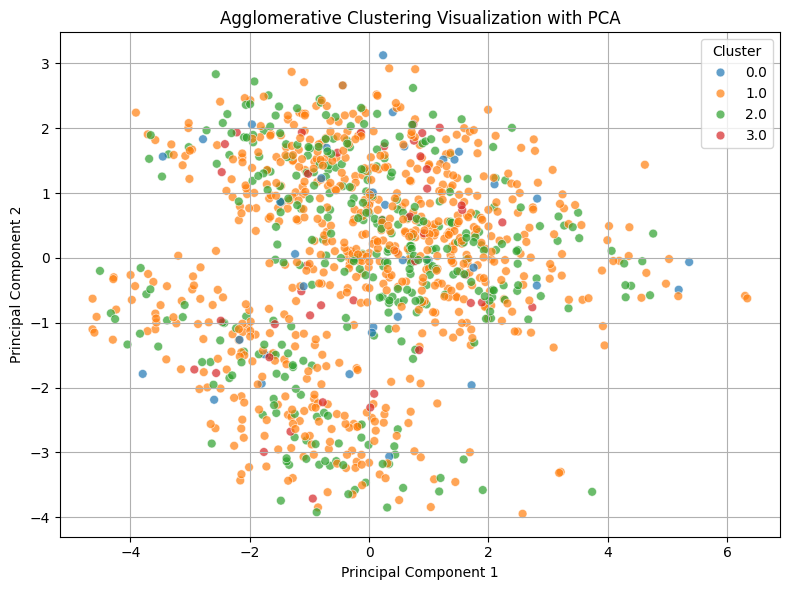

In [71]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca_agg = pca.fit_transform(df_hierarchical.drop('Cluster', axis=1))

df_pca_agg = pd.DataFrame(X_pca_agg, columns=['PCA1', 'PCA2'])
df_pca_agg['Cluster'] = df_hierarchical['Cluster']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_agg, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.7)

plt.title('Agglomerative Clustering Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


* 2 Clusters:

In [72]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

df_hierarchical.columns = df_hierarchical.columns.astype(str)

Agglomerative = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_Agglomerative = Agglomerative.fit_predict(df_hierarchical)

df_hierarchical['Cluster'] = y_Agglomerative
df_hierarchical['Cluster'].value_counts()

,count
Cluster,
0,6489
1,3511


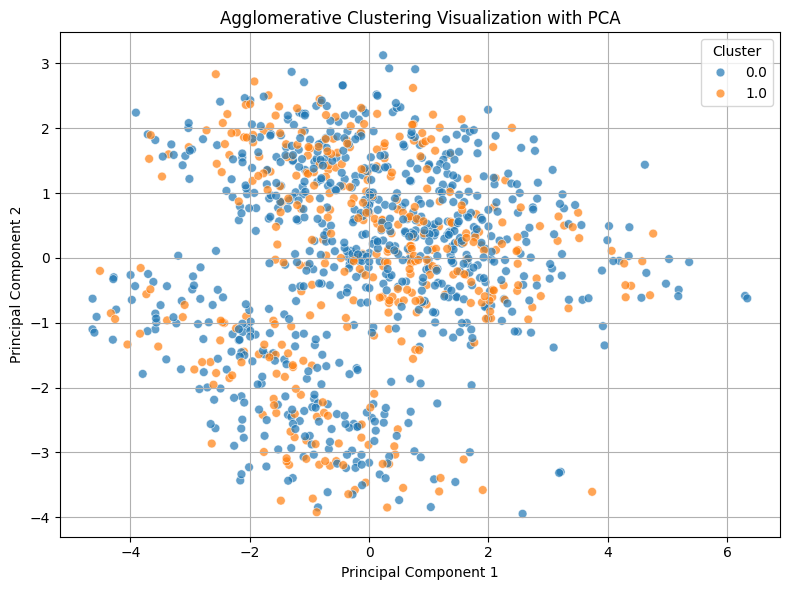

In [73]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca_agg = pca.fit_transform(df_hierarchical.drop('Cluster', axis=1))

df_pca_agg = pd.DataFrame(X_pca_agg, columns=['PCA1', 'PCA2'])
df_pca_agg['Cluster'] = df_hierarchical['Cluster']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_agg, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.7)

plt.title('Agglomerative Clustering Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


### DBSCAN

* Find a good eps using the k-distance plot

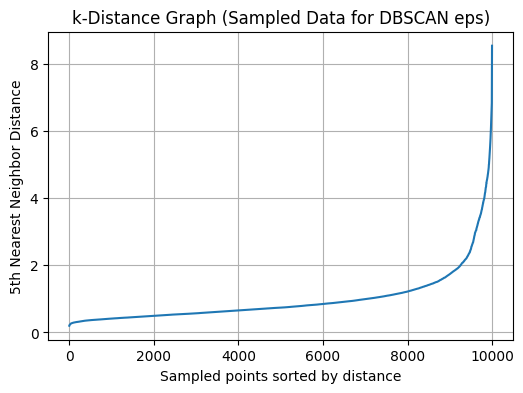

In [74]:
from sklearn.neighbors import NearestNeighbors

# Sample the data to reduce memory usage
sample_size = 10000
np.random.seed(42)
sample_indices = np.random.choice(df_reduced.shape[0], sample_size, replace=False)
df_sampled = df_reduced[sample_indices]

# Compute k-distance plot
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_sampled)
distances, indices = neighbors_fit.kneighbors(df_sampled)

# Sort and plot
distances = np.sort(distances[:, 4])  # 5th nearest neighbor
plt.figure(figsize=(6, 4))
plt.plot(distances)
plt.title('k-Distance Graph (Sampled Data for DBSCAN eps)')
plt.xlabel('Sampled points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

* Run DBSCAN:

In [87]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=6, min_samples=5)
dbscan.fit(df_sampled)


df_dbscan = pd.DataFrame(df_sampled)
df_dbscan['cluster'] = dbscan.labels_


* Visualize:

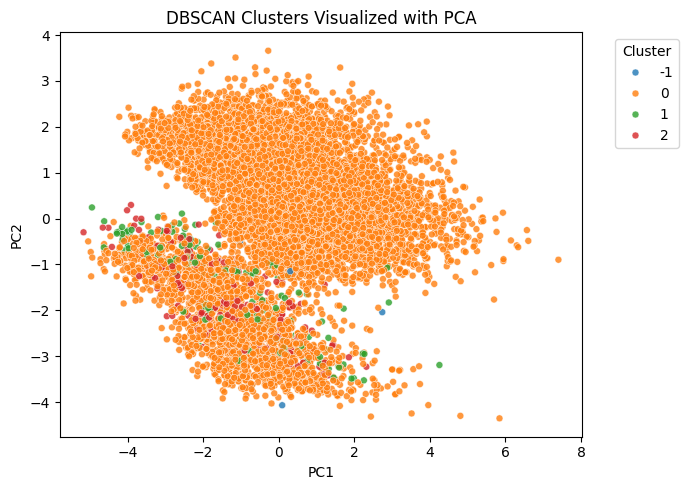

In [88]:
pca_result_sampled = pca.fit_transform(df_sampled)
df_dbplot = pd.DataFrame(pca_result_sampled, columns=['PC1', 'PC2'])
df_dbplot['Cluster'] = dbscan.labels_

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_dbplot, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('DBSCAN Clusters Visualized with PCA')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Cluster Profiling & Business Insight

### KMeans

In [108]:
def profile_clusters(df, cluster_col='cluster'):
    # List numeric and categorical columns
    numeric_cols = df.select_dtypes(include='number').columns
    if cluster_col in numeric_cols:
        numeric_cols = numeric_cols.drop(cluster_col)

    categorical_cols = df.select_dtypes(include='object').columns

    cluster_profiles = []

    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        profile = {'Cluster': cluster_id, 'Count': len(cluster_data)}

        # Numeric stats: mean
        for col in numeric_cols:
            profile[f'{col}_mean'] = cluster_data[col].mean()

        # Categorical stats: mode (most frequent)
        for col in categorical_cols:
            if len(cluster_data) > 0:
                mode_val = cluster_data[col].mode()
                profile[f'{col}_mode'] = mode_val.iloc[0] if not mode_val.empty else None
            else:
                profile[f'{col}_mode'] = None

        cluster_profiles.append(profile)

    return pd.DataFrame(cluster_profiles)


# Example for kmeans
kmeans_profile = profile_clusters(df_kmeans, cluster_col='cluster')
kmeans_profile


,Cluster,Count,0_mean,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean,...,11_mean,12_mean,13_mean,14_mean,15_mean,16_mean,17_mean,18_mean,19_mean,20_mean
0,0,29113,-0.866368,1.528932,0.302575,0.013559,-0.018034,-0.368261,-0.067217,-0.143959,...,0.117624,0.011133,-0.010856,-0.005217,-0.081863,-0.027741,-0.085617,0.004951,-0.001635,0.014891
1,1,21315,-1.194855,-2.096511,1.059097,-0.111162,0.030084,0.087421,-0.012050,-0.043953,...,-0.164513,0.081190,-0.017250,-0.034123,-0.017345,0.001652,0.087167,-0.029760,0.011787,0.094395
2,2,40515,1.251164,0.004328,-0.774615,0.048740,-0.002868,0.218630,0.054640,0.126569,...,0.002029,-0.050714,0.016876,0.021701,0.067950,0.019065,0.015664,0.012100,-0.005026,-0.060362


In [109]:
def assign_labels(profile_df):
    labels = []
    for _, row in profile_df.iterrows():
        # Adjust index numbers based on your actual column meanings:
        price_mean_idx = 3     # e.g. column '3_mean' corresponds to 'price_mean'
        payment_type_idx = 7   # e.g. column '7_mode' corresponds to 'payment_type_get_mode'
        distance_mean_idx = 11 # e.g. column '11_mean' corresponds to 'order_distance_mean'

        if row[f'{price_mean_idx}_mean'] > 1000 and row[f'{payment_type_idx}_mode'] == 'credit_card':
            labels.append('Premium Buyers')
        elif row[f'{distance_mean_idx}_mean'] > 50:
            labels.append('Distant Customers')
        else:
            labels.append('Regular Buyers')

    profile_df['Marketing Label'] = labels
    return profile_df


kmeans_profile = assign_labels(kmeans_profile)
kmeans_profile[['Cluster', 'Marketing Label']]


,Cluster,Marketing Label
0,0,Regular Buyers
1,1,Regular Buyers
2,2,Regular Buyers


In [110]:
recommendations = {
    'Premium Buyers': [
        'Offer exclusive discounts on high-end products',
        'Send personalized loyalty perks and premium support'
    ],
    'Distant Customers': [
        'Optimize shipping logistics and partner with local couriers',
        'Offer free shipping for orders above a certain value'
    ],
    'Regular Buyers': [
        'Promote bundle offers to increase average order value',
        'Send regular newsletters with product updates'
    ]
}

kmeans_profile['Recommendations'] = kmeans_profile['Marketing Label'].map(recommendations)
kmeans_profile[['Cluster', 'Marketing Label', 'Recommendations']]


,Cluster,Marketing Label,Recommendations
0,0,Regular Buyers,[Promote bundle offers to increase average ord...
1,1,Regular Buyers,[Promote bundle offers to increase average ord...
2,2,Regular Buyers,[Promote bundle offers to increase average ord...


### Hierarchical

In [114]:
hier_profile = profile_clusters(df_hierarchical, cluster_col='Cluster')
hier_profile

,Cluster,Count,0_mean,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean,...,11_mean,12_mean,13_mean,14_mean,15_mean,16_mean,17_mean,18_mean,19_mean,20_mean
0,0,6489,0.023188,-0.023115,0.054965,-0.635724,0.291287,0.102863,0.057454,-0.105590,...,0.016128,0.032829,-0.068772,-0.031057,0.049672,-0.015019,0.091808,0.150007,-0.02225,-0.177369
1,1,3511,-0.058517,-0.010982,-0.043663,1.165284,-0.550664,-0.209707,-0.069023,0.237078,...,-0.011899,-0.037972,0.128646,0.098966,-0.070364,0.029122,-0.167157,-0.311235,-0.00184,0.371245


In [115]:
hier_profile = assign_labels(hier_profile)
hier_profile[['Cluster', 'Marketing Label']]

,Cluster,Marketing Label
0,0,Regular Buyers
1,1,Regular Buyers


In [116]:
hier_profile['Recommendations'] = hier_profile['Marketing Label'].map(recommendations)
hier_profile[['Cluster', 'Marketing Label', 'Recommendations']]

,Cluster,Marketing Label,Recommendations
0,0,Regular Buyers,[Promote bundle offers to increase average ord...
1,1,Regular Buyers,[Promote bundle offers to increase average ord...


### DBSCAN

In [117]:
db_profile = profile_clusters(df_dbscan, cluster_col='cluster')
db_profile

,Cluster,Count,0_mean,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean,...,11_mean,12_mean,13_mean,14_mean,15_mean,16_mean,17_mean,18_mean,19_mean,20_mean
0,-1,10,-0.592089,-0.452026,-0.321386,-1.852447,-1.872756,0.690659,-2.136633,-1.659200,...,0.228454,-0.412303,-1.567643,-2.189856,0.081141,1.070165,-0.096331,2.458417,10.846368,1.906878
1,0,9641,0.046606,0.039620,0.006958,-0.005908,-0.000920,-0.016150,-0.014712,0.029727,...,0.024473,-0.041178,0.049430,0.084548,0.032718,-0.023524,-0.127896,-0.041214,-0.014541,-0.018164
2,1,163,-1.254734,-1.500884,1.042716,-0.021046,0.303075,-0.259414,0.999172,0.072081,...,1.212286,0.929703,-1.135727,-1.337194,0.546592,2.051426,6.135905,-3.055736,1.087273,-0.923243
3,2,186,-1.579936,-1.727759,-0.163754,0.241989,-0.349562,0.657375,0.703336,-0.723359,...,-2.005136,1.770384,-1.453410,-2.308227,-1.774522,-0.610234,1.304884,4.040284,-1.593231,2.467906


In [118]:
db_profile = assign_labels(db_profile)
db_profile[['Cluster', 'Marketing Label']]

,Cluster,Marketing Label
0,-1,Regular Buyers
1,0,Regular Buyers
2,1,Regular Buyers
3,2,Regular Buyers


In [119]:
db_profile['Recommendations'] = db_profile['Marketing Label'].map(recommendations)
db_profile[['Cluster', 'Marketing Label', 'Recommendations']]

,Cluster,Marketing Label,Recommendations
0,-1,Regular Buyers,[Promote bundle offers to increase average ord...
1,0,Regular Buyers,[Promote bundle offers to increase average ord...
2,1,Regular Buyers,[Promote bundle offers to increase average ord...
3,2,Regular Buyers,[Promote bundle offers to increase average ord...
